# Toroidal VAE
### Template Space S¹x...xS¹

In [188]:
import os
import sys

mvae_dir = os.path.split(os.getcwd())[0]
if mvae_dir not in sys.path:
    sys.path.append(mvae_dir)

In [189]:
%pwd
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [190]:
import torch
import numpy as np
import torch.optim as optim

import lib.dataloaders.synthetic_loader as dataloader
import lib.models.vae.vm_toroidal_vae as model
from lib.models.utils.save_load_models import save_model
import lib.trainer as trainer
import lib.utils as utils

from types import SimpleNamespace



### General set up

In [191]:
# Set random seed for reproducibility
torch.manual_seed(59)
np.random.seed(49)

### Experiment Configurations

In [192]:
loader_config = {
    "dataset_name": "s1_synthetic",
    "batch_size": 128,
    "rotation": "random",
    "n_times": 10000,
    "radius": 2.0,
    "major_radius": 3.0,
    "minor_radius": 1.0,
    "n_wiggles": 0,
    "geodesic_distortion_amp": 0.3,
    "embedding_dim": 10,
    "noise_var": 0.0001,
    "geodesic_distortion_func": "wiggles",
    "plot_dataset": True
}

model_config = {
    'model_type': 'VonMisesVAE',
    'data_dim': loader_config["embedding_dim"],
    'latent_dim': 1,
    'sftbeta': 4.5,
    'device': "cpu",
    'encoder_widths': [8, 5],
    'decoder_widths': [100],
}

optimizer_config = {
    "learning_rate": 0.001,
}

trainer_config = {
    'num_epochs': 1,
    'log_interval': 100,
    'recon_loss': "MSE",
    'topo_loss': False,
    'alpha': 1.0,  # Weight for reconstruction loss
    'beta': .1,  # Weight for KL loss
    'gamma': 1.0,  # Weight for topological loss
}

curvature_config = {
    "n_grid_points": 2000,  # to compute curvature
}

config_dict = {}
config_dict.update(loader_config)
config_dict.update(model_config)
config_dict.update(optimizer_config)
config_dict.update(trainer_config)
config_dict.update(curvature_config)

config = SimpleNamespace(**config_dict)

 ### Dataloader

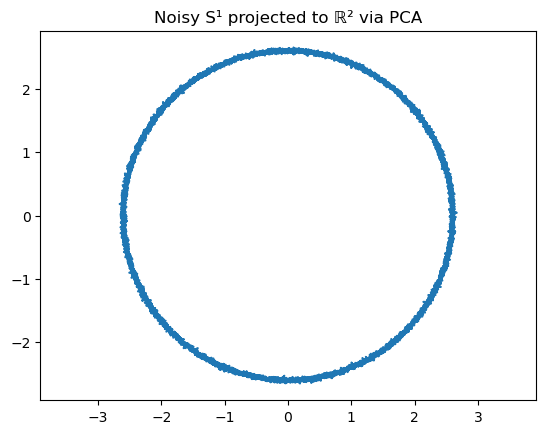

In [193]:
dataloader = dataloader.load_synthetic_ds(config)
train_loader, test_loader = dataloader

### Model

In [194]:
model = model.VMToroidalVAE(config)

### Optimizer

In [195]:
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)

### Train and evaluate model

In [196]:
history = trainer.MVAETrainer(model, dataloader, optimizer, config).train()

Trainer successfully initialized.
Training the vm_toroidalVAE model.
Starting epoch 1/1
Epoch 1/1, Train Loss: 6.9039, Test Loss: 6.7157
--------------------------------------------------


### Visualization 

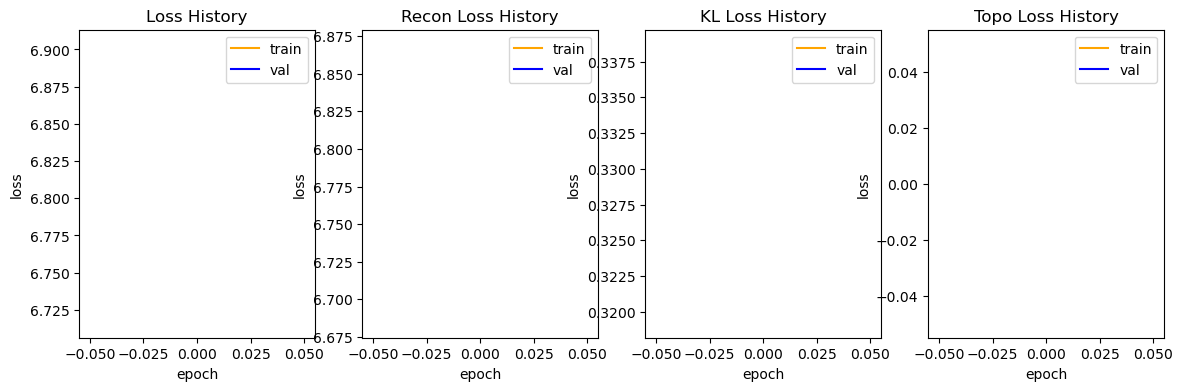

In [197]:
utils.show_training_history(history)

#### Plot latent space

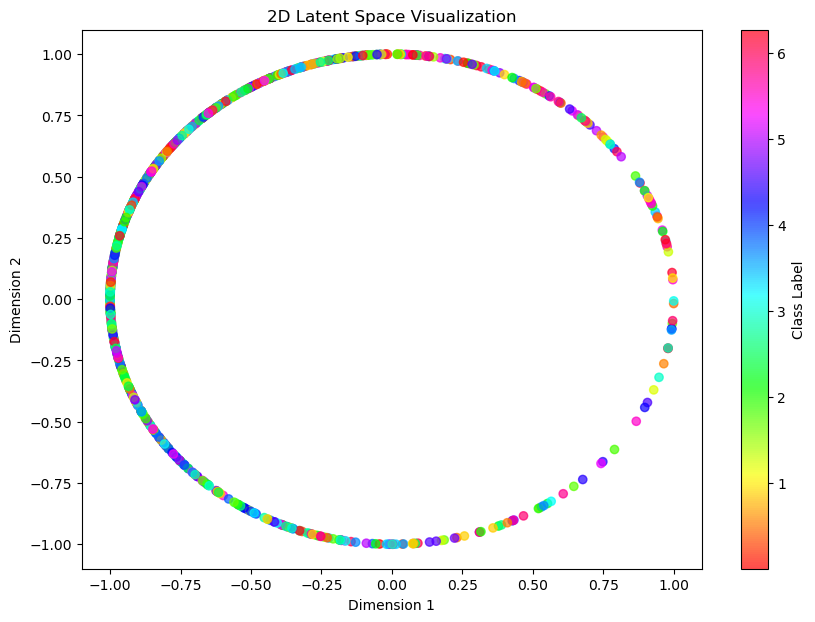

In [198]:
utils.plot_euclidean_latent_space(model, test_loader, n_samples=10000)

### Plot reconstructed manifold

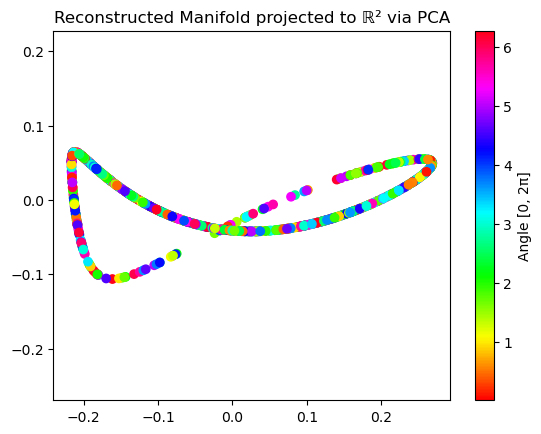

In [199]:
utils.plot_recon_manifold(model, test_loader, n_samples=1000)

In [200]:
utils.compute_curvature_learned(model, test_loader, config, n_grid_points=2000)

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/timtom/miniconda3/envs/mvae-env/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3526, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_16777/1310420629.py", line 1, in <module>
    utils.compute_curvature_learned(model, test_loader, config, n_grid_points=2000)
  File "/home/timtom/Documents/uni_math/diplomarbeit/code/mvae/lib/utils/evaluation.py", line 173, in compute_curvature_learned
    result = _compute_curvature(z_grid, immersion, z_grid.shape[1], config.embedding_dim)
IndexError: tuple index out of range

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/timtom/miniconda3/envs/mvae-env/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 2120, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
  File "/home/timtom/miniconda3/envs/mvae-env/lib/python3.9/site-packages/IPython/

#### Compute curvature error

In [ ]:
utils.curvature_compute_plot_vm(config, model, test_loader)

### Save trained models

In [ ]:
#save_model(model, config)

### Load pretrained models

In [ ]:
#model = modelutils.load_model("gaussian_1740054584")
#model = model